<div align="center">

**CIVE 7100: Time Series and Geospatial Data Science**

Northeastern University

</div>

**Final Project: Step 04 - Model Selection**

Juan Cruz Ferreyra

---

## Methodology and Objectives

This notebook performs systematic model selection for forecasting morning bike-share demand at a representative station. We analyze both pickup and dropoff demand (5:00-10:59 AM aggregated daily) to identify optimal SARIMA specifications that balance goodness of fit with parsimony.

The analysis follows standard ARIMA methodology: we begin with ACF examination of raw data to assess stationarity and identify seasonal patterns. Based on visual evidence of non-stationarity and persistent weekly cycles, we apply first differencing to achieve stationarity. ACF and PACF analysis of the differenced series guides initial model specifications, identifying appropriate autoregressive and moving average orders for both non-seasonal and seasonal components.

We test four candidate SARIMA models reflecting different combinations of AR and MA structure while maintaining consistent weekly seasonal components. Models are fit on the complete dataset and compared using AIC (Akaike Information Criterion), which balances likelihood against parameter complexity to prevent overfitting. The selected model provides the foundation for operational forecasting in subsequent analysis.

Finally, we explore whether exogenous weather variables (temperature, precipitation, snow, wind) improve forecast performance by examining cross-correlations with model residuals. If weather correlates with residuals, it indicates predictive information not captured by temporal structure alone, motivating SARIMAX extension. If correlations appear only in raw data but not residuals, this confirms the SARIMA specification already accounts for weather effects through its temporal components.

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

from bluebikes_analysis.config import LOCAL_DATA_DIR
from bluebikes_analysis.plots import (
    COLORS,
    plot_correlation_comparison,
    plot_crosscorrelation_comparison,
    plot_daily_longterm,
)

In [2]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "trips"

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"
df_station = pd.read_csv(station_file)

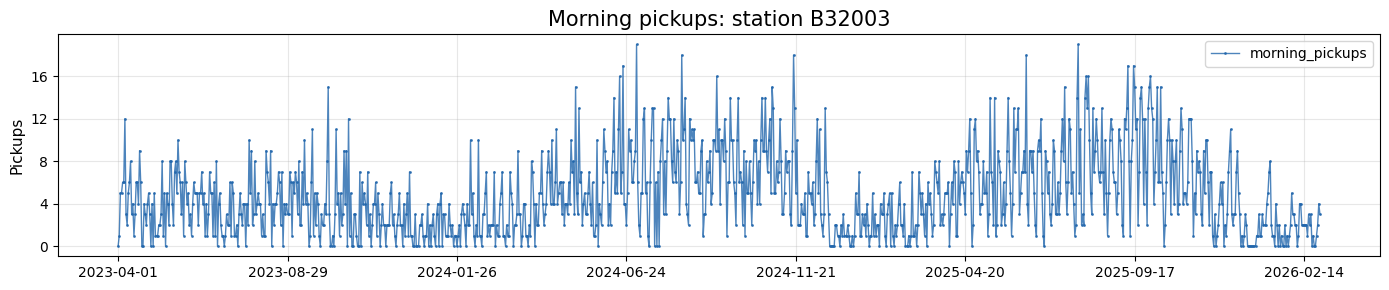

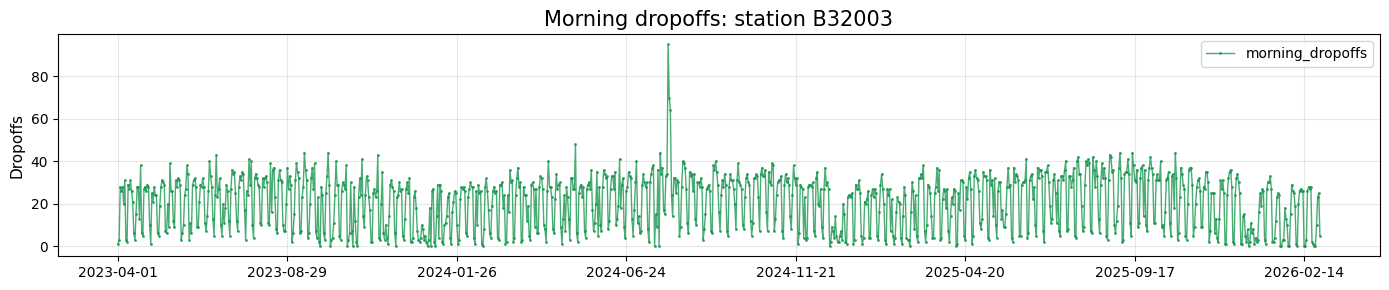

In [3]:
# Set index for plotting
df_daily_indexed = df_station.set_index('date')

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['morning_pickups'],
    title=f'Morning pickups: station {station_name}',
    ylabel='Pickups',
    color_list=[COLORS[7]],
    figsize=(14, 3)
)

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['morning_dropoffs'],
    title=f'Morning dropoffs: station {station_name}',
    ylabel='Dropoffs',
    color_list=[COLORS[5]],
    figsize=(14, 3)
)

## Model Identification: ACF and PACF Analysis

Following standard ARIMA methodology, we examine the autocorrelation structure to guide model specification. We first inspect the raw data's Autocorrelation Function (ACF) to assess stationarity and identify differencing requirements. A slowly decaying ACF indicates non-stationarity, requiring differencing to achieve a stationary mean. Periodic spikes in the ACF reveal seasonal patterns that, if persistent after differencing, indicate the need for seasonal ARIMA components to model cyclic dependencies explicitly.

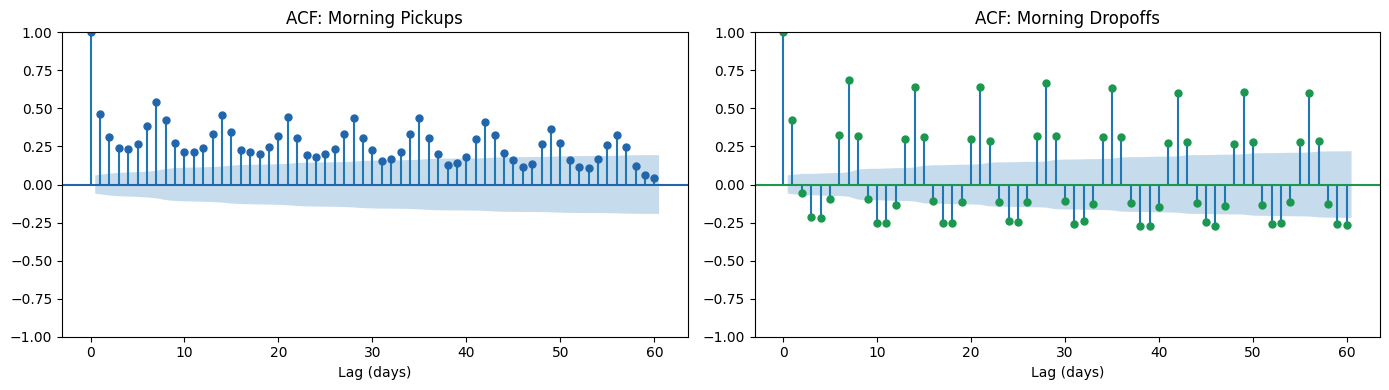

In [4]:
plot_correlation_comparison(
    df_daily_indexed,
    columns_to_compare=['morning_pickups', 'morning_dropoffs'],
    titles=['ACF: Morning Pickups', 'ACF: Morning Dropoffs'],
    color_list=[COLORS[7], COLORS[5]],
    figsize=(14, 4)
)

**Pickup demand:** The ACF shows gradual decay with superimposed weekly periodicity. Correlation starts at ρ₁ = 0.48 and builds through the week to ρ₇ = 0.55, then repeats with diminishing strength at multiples of 7 (ρ₁₄, ρ₂₁...). The slow overall decay confirms non-stationarity requiring differencing ($d=1$), while the regular 7-day spikes indicate weekly seasonality necessitating SARIMA seasonal components.

**Dropoff demand:** The ACF exhibits oscillating behavior within the weekly cycle—positive at lag 1 (ρ₁ = 0.45), negative at lags 2-5 (ρ₃ ≈ -0.25), recovering to a strong weekly peak (ρ₇ = 0.75). This oscillation suggests compensating dynamics (high dropoffs followed by low dropoffs), while the stronger weekly correlation (0.75 vs pickups' 0.55) indicates more rigid weekly structure. The pattern confirms non-stationarity and weekly seasonality.

Both series require first differencing ($d=1$) to remove trend and seasonal ARIMA components (period $s=7$) to model the persistent weekly patterns. We proceed to ACF/PACF analysis of differenced data to determine specific AR and MA orders.

### Transformation for Stationarity

The ACF analysis confirms non-stationarity in both series through slow decay patterns, consistent with findings from the stationarity analysis notebook (`02_stationarity_test.ipynb`). We apply first differencing to remove the trend component. While dropoff demand showed borderline stationarity in formal testing (ADF p-value = 0.006), the persistent autocorrelation structure and slow ACF decay motivate differencing for both series, ensuring methodological consistency and interpretable differenced values representing day-to-day changes in demand.

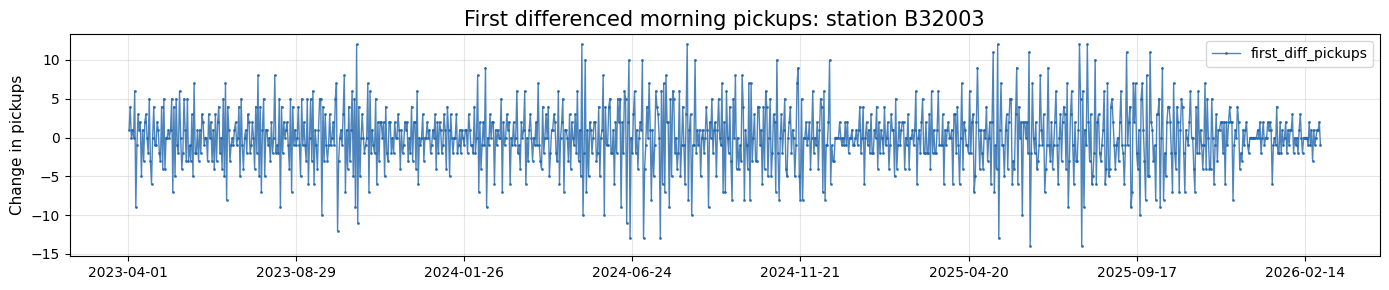

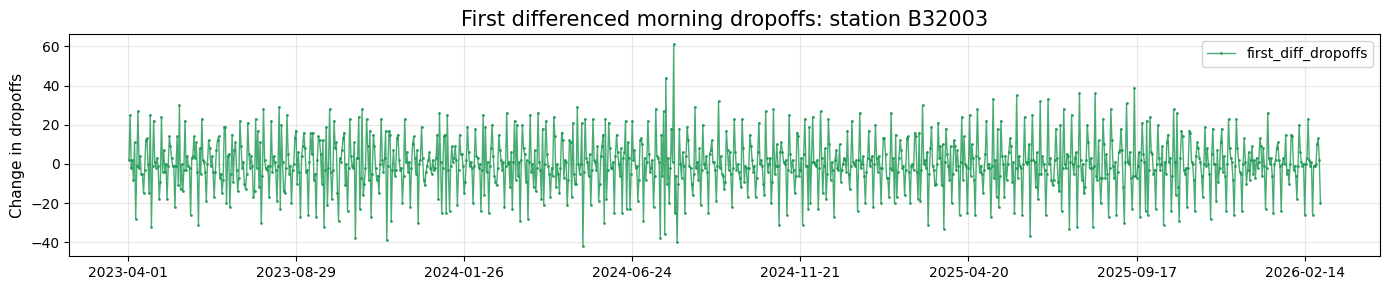

In [5]:
# Apply first differencing
df_station['first_diff_pickups'] = df_station['morning_pickups'].diff()
df_station['first_diff_dropoffs'] = df_station['morning_dropoffs'].diff()

# Set index for plotting
df_daily_indexed = df_station.set_index('date')

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['first_diff_pickups'],
    title=f'First differenced morning pickups: station {station_name}',
    ylabel='Change in pickups',
    color_list=[COLORS[7]],
    figsize=(14, 3)
)

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['first_diff_dropoffs'],
    title=f'First differenced morning dropoffs: station {station_name}',
    ylabel='Change in dropoffs',
    color_list=[COLORS[5]],
    figsize=(14, 3)
)

### ACF and PACF Analysis: Differenced Series

We examine the autocorrelation structure of first-differenced data to determine model orders using standard ARIMA identification rules:

**Non-seasonal component identification (short lags):**
- PACF cuts off sharply after lag k: suggests AR(k)
- ACF cuts off sharply after lag k: suggests MA(k)
- Both decay gradually: suggests ARMA (mixed AR and MA components)

**Seasonal component identification:**
When periodic patterns exist, ACF and PACF must be examined together to distinguish between regular autoregressive structure and seasonal dependencies. A pattern at the seasonal lag can represent either individual lag effects or a repeating cycle.

The key diagnostic is examining ACF at multiples of the suspected period. If spikes appear regularly at lags 7, 14, 21, this confirms seasonal structure warranting SARIMA seasonal components at period s. Without this repetition, the pattern reflects standard AR or MA structure at that specific lag.

In differenced series, intermediate lags can capture information about the seasonal lag indirectly. For instance, lag 6 in a first-differenced series involves the term $Y_{t-7}$, potentially obscuring the direct seasonal effect when examining PACF. This underscores the importance of using ACF's repeating pattern as the primary seasonal diagnostic, with PACF providing supplementary information about the nature of the seasonal dependency.

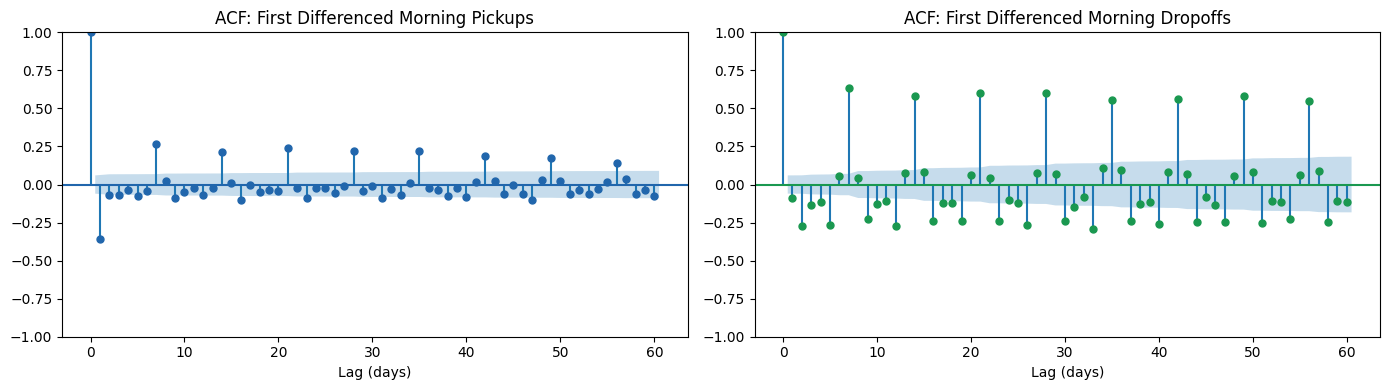

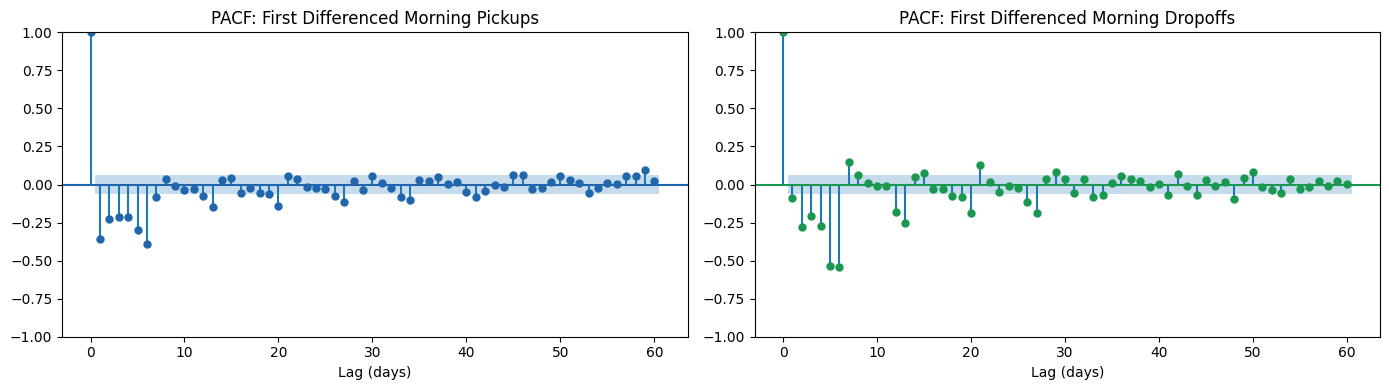

In [6]:
plot_correlation_comparison(
    df_daily_indexed,
    columns_to_compare=['first_diff_pickups', 'first_diff_dropoffs'],
    plot_type="acf",
    titles=['ACF: First Differenced Morning Pickups', 'ACF: First Differenced Morning Dropoffs'],
    color_list=[COLORS[7], COLORS[5]],
    figsize=(14, 4)
)

plot_correlation_comparison(
    df_daily_indexed,
    columns_to_compare=['first_diff_pickups', 'first_diff_dropoffs'],
    plot_type="pacf",
    titles=['PACF: First Differenced Morning Pickups', 'PACF: First Differenced Morning Dropoffs'],
    color_list=[COLORS[7], COLORS[5]],
    figsize=(14, 4)
)

**Interpretation: Pickups Demand**

**ACF pattern:** Strong negative correlation at lag 1 (ρ₁ = -0.36) followed by weak negative values at lags 2-6, then a positive spike at lag 7 (ρ₇ = 0.27). This pattern repeats at lag 14 (ρ₁₄ = 0.22), confirming weekly seasonality. The negative lag-1 correlation is a typical differencing artifact, while the repeating 7-day spikes indicate persistent weekly cycles.

**PACF pattern:** Sharp negative correlation at lag 1 (φ₁ = -0.36) matching the ACF, followed by significant negative values through lag 6 (φ₆ = -0.39), then an abrupt drop at lag 7 (φ₇ = -0.09). At first glance, this cutoff at lag 6 might suggest AR(6) structure. However, this interpretation requires caution due to the differencing operation: the differenced value at lag 6 contains the term $Y_{t-7}$ (as $Y_{t-6} - Y_{t-7}$), meaning lag 6 inherently captures weekly information. The sharp drop at lag 7 occurs because lag 6 already accounts for much of the weekly effect. Cross-referencing with the ACF's repeating pattern at multiples of 7 confirms this is **seasonal structure, not AR(6)**—the PACF cutoff reflects how the weekly dependency is distributed across the differenced lag structure rather than indicating six independent AR parameters.

**Model implications:** The negative ρ₁ matching φ₁ suggests **MA(1)** for the non-seasonal component (q=1). The weekly pattern visible in ACF repetition, combined with the PACF structure, indicates **Seasonal AR(1)** at period 7 (P=1, s=7). Preliminary specification: **SARIMA(0,1,1)(1,0,0)₇**.

---

**Interpretation: Dropoffs Demand**

**ACF pattern:** Weak negative correlation at lag 1 (ρ₁ = -0.09), followed by oscillating negative values at lags 2-5 (ρ₂ = -0.27, ρ₅ = -0.26), then a very strong positive spike at lag 7 (ρ₇ = 0.63). This pattern repeats robustly at lag 14 (ρ₁₄ = 0.58), confirming strong weekly seasonality. The oscillating mid-week pattern suggests compensating dynamics within the weekly cycle.

**PACF pattern:** Weak initial correlation (φ₁ = -0.09), then significant negative values building through lags 2-6 (φ₅ = -0.54, φ₆ = -0.55), followed by a positive value at lag 7 (φ₇ = 0.14), then near-zero afterward. The gradual buildup through lag 6 followed by the drop suggests the differencing effect described previously—lag 6 captures weekly information through its $Y_{t-7}$ term. The positive φ₇ (unlike pickups' negative) indicates a direct seasonal AR effect after controlling for intermediate lags.

**Model implications:** The weak ρ₁ suggests minimal non-seasonal MA component, but the oscillating ACF pattern (negative lags 2-5) and decaying PACF indicate **MA(2)** might capture mid-week dynamics (q=2 or q=1). The extremely strong ρ₇ = 0.63 and repeating pattern definitively indicate **Seasonal AR(1)** (P=1, s=7). Preliminary specification: **SARIMA(0,1,1)(1,0,0)₇** or **SARIMA(0,1,2)(1,0,0)₇**.

## Model Selection Strategy

Based on ACF/PACF analysis, we test four SARIMA specifications for both pickup and dropoff demand. While correlation patterns differ slightly between series, we prioritize methodological consistency and test the same model set for both.

**Model 1: SARIMA(0,1,1)(1,0,0)₇** - ACF-guided baseline
- Non-seasonal: MA(1) based on negative ρ₁
- Seasonal: AR(1) at weekly period based on repeating ρ₇, ρ₁₄ pattern
- Rationale: Minimal specification capturing identified structure

**Model 2: SARIMA(0,1,2)(1,0,0)₇** - Extended MA
- Non-seasonal: MA(2) to capture mid-week oscillations
- Seasonal: Weekly AR(1)
- Rationale: Tests whether additional MA term improves fit

**Model 3: SARIMA(1,1,1)(1,0,0)₇** - AR augmented
- Non-seasonal: Adds AR(1) component
- Seasonal: Weekly AR(1)
- Rationale: Evaluates whether AR structure improves performance beyond MA alone

**Model 4: SARIMA(1,1,2)(1,0,0)₇** - Full non-seasonal ARMA
- Non-seasonal: AR(1) and MA(2) combination
- Seasonal: Weekly AR(1)
- Rationale: Tests whether combining AR and extended MA provides further improvement

We compare models using AIC as the primary selection criterion. The selected model balances parsimony with goodness of fit.

ACF/PACF patterns suggest MA(1) for non-seasonal component and Seasonal AR(1) for weekly structure, yielding preliminary specification SARIMA(0,1,1)(1,0,0)₇. However, we also test specifications with AR(1) terms to evaluate whether additional autoregressive structure not immediately obvious from visual inspection improves model performance. This exploratory approach acknowledges that ACF/PACF provide guidance rather than definitive answers, particularly when differencing artifacts may obscure underlying AR dependencies.

## Model Training and Comparison

We fit each candidate model on the complete dataset and compare using AIC (Akaike Information Criterion):

$$\text{AIC} = -2\log(\mathcal{L}) + 2k$$

where $\mathcal{L}$ is the maximum likelihood and $k$ is the number of estimated parameters. AIC balances goodness of fit (log-likelihood) against model complexity (parameter count), penalizing additional parameters to prevent overfitting. The model with the lowest AIC provides the best trade-off between capturing temporal structure and maintaining parsimony.

In [7]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Define models to test
model_specs = {
    'Model 1': ((0, 1, 1), (1, 0, 0, 7)),
    'Model 2': ((0, 1, 2), (1, 0, 0, 7)),
    'Model 3': ((1, 1, 1), (1, 0, 0, 7)),
    'Model 4': ((1, 1, 2), (1, 0, 0, 7)),
}

# Prepare data
series_dict = {
    'Pickups': df_station['morning_pickups'].dropna(),
    'Dropoffs': df_station['morning_dropoffs'].dropna()
}

# Fit models for both series
all_results = {}

for series_name, train_data in series_dict.items():
    print("="*60)
    print(f"FITTING MODELS: {series_name.upper()}")
    print("="*60)
    
    results = []
    for model_name, (order, seasonal_order) in model_specs.items():
        print(f"\n{model_name}: SARIMA{order}{seasonal_order}")
        
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order).fit(disp=False)
        
        results.append({
            'Model': model_name,
            'Specification': f"SARIMA{order}{seasonal_order}",
            'AIC': model.aic,
            'BIC': model.bic,
            'Log-Likelihood': model.llf
        })
        
        print(f"  AIC: {model.aic:.2f}")
    
    all_results[series_name] = pd.DataFrame(results)

# Display comparison tables
for series_name, df_results in all_results.items():
    print("\n" + "="*60)
    print(f"MODEL COMPARISON: {series_name.upper()}")
    print("="*60)
    print(df_results.to_string(index=False))

FITTING MODELS: PICKUPS

Model 1: SARIMA(0, 1, 1)(1, 0, 0, 7)
  AIC: 5429.14

Model 2: SARIMA(0, 1, 2)(1, 0, 0, 7)
  AIC: 5402.40

Model 3: SARIMA(1, 1, 1)(1, 0, 0, 7)
  AIC: 5399.92

Model 4: SARIMA(1, 1, 2)(1, 0, 0, 7)
  AIC: 5401.67
FITTING MODELS: DROPOFFS

Model 1: SARIMA(0, 1, 1)(1, 0, 0, 7)
  AIC: 7762.02

Model 2: SARIMA(0, 1, 2)(1, 0, 0, 7)
  AIC: 7644.77

Model 3: SARIMA(1, 1, 1)(1, 0, 0, 7)
  AIC: 7633.62

Model 4: SARIMA(1, 1, 2)(1, 0, 0, 7)
  AIC: 7635.32

MODEL COMPARISON: PICKUPS
  Model               Specification         AIC         BIC  Log-Likelihood
Model 1 SARIMA(0, 1, 1)(1, 0, 0, 7) 5429.142740 5444.052112    -2711.571370
Model 2 SARIMA(0, 1, 2)(1, 0, 0, 7) 5402.401902 5422.281065    -2697.200951
Model 3 SARIMA(1, 1, 1)(1, 0, 0, 7) 5399.918027 5419.797189    -2695.959013
Model 4 SARIMA(1, 1, 2)(1, 0, 0, 7) 5401.667282 5426.516236    -2695.833641

MODEL COMPARISON: DROPOFFS
  Model               Specification         AIC         BIC  Log-Likelihood
Model 1 SARIMA(0

All four candidate models successfully converged for both pickup and dropoff series. AIC comparison reveals consistent patterns across both demand types.

**Pickup Demand:**
Model 3 (SARIMA(1,1,1)(1,0,0)₇, AIC = 5399.92) achieves the lowest AIC, narrowly outperforming Model 4 by 1.7 points. The progression shows that adding MA(2) (Model 1→2) provides substantial improvement (27 AIC points), while incorporating AR(1) (Model 2→3) yields further gains (2.5 points). Model 4's additional MA parameter provides negligible benefit (increases AIC by 1.7), suggesting overfitting.

**Dropoff Demand:**
Model 3 (SARIMA(1,1,1)(1,0,0)₇, AIC = 7633.62) emerges as the clear winner. The improvement from baseline Model 1 is dramatic (128 AIC points total), with MA(2) contributing the majority (117 points, Model 1→2) and AR(1) adding 11 points (Model 2→3). This substantial improvement confirms the oscillating mid-week pattern observed in ACF analysis requires MA structure. Model 4 again shows no improvement over Model 3, reinforcing that the simpler specification is sufficient.

**Selected Model:** SARIMA(1,1,1)(1,0,0)₇ provides the optimal balance of fit and parsimony for both series. The consistent performance across pickup and dropoff demand validates using a unified model specification for both forecasting tasks, simplifying operational implementation while maintaining statistical rigor.

## Extension: SARIMAX with Exogenous Weather Variables

The selected SARIMA model captures temporal dependencies through autoregressive and moving average structures, including trend and weekly seasonality. However, weather conditions may explain additional variance beyond these temporal patterns. We test whether incorporating exogenous weather variables improves model performance by examining whether environmental factors correlate with SARIMA residuals.

Weather data from NOAA's NCEI database (GHCND dataset, Boston Logan Airport station) provides daily measurements of maximum temperature (TMAX), minimum temperature (TMIN), precipitation (PRCP), snowfall (SNOW), and average wind speed (AWND) for the analysis period. We first fit the best SARIMA model (Model 3), extract its residuals, then use cross-correlation functions to identify which weather variables exhibit relationships with unexplained demand variation. Significant weather predictors are incorporated as exogenous regressors in SARIMAX, and AIC comparison determines whether weather information provides meaningful improvement beyond pure time series structure.

In [8]:
weather_dir = LOCAL_DATA_DIR / "processed" / "weather"

weather_file = weather_dir / f"daily_weather.csv"
df_weather = pd.read_csv(weather_file)

filt = (df_weather["date"] >= df_station["date"].min()) & (df_weather["date"] <= df_station["date"].max())
df_weather = df_weather.loc[filt, :]

In [9]:
df_weather.head()

,date,AWND,PRCP,SNOW,TMAX,TMIN
1916,2023-04-01,6.9,0.35,0.0,63.0,41.0
1917,2023-04-02,16.6,0.00,0.0,55.0,35.0
1918,2023-04-03,12.3,0.00,0.0,52.0,31.0
1919,2023-04-04,7.6,0.00,0.0,54.0,43.0
1920,2023-04-05,14.3,0.00,0.0,49.0,39.0


### Fitting Selected Model and Extracting Residuals

To evaluate whether weather variables explain variance beyond temporal structure, we first fit the selected SARIMA(1,1,1)(1,0,0)₇ model to both pickup and dropoff series and extract residuals. These residuals represent the portion of demand variation unexplained by trend, weekly seasonality, and autoregressive dynamics. If weather conditions correlate significantly with these residuals, it indicates environmental factors influence demand independently of the temporal patterns already captured by SARIMA, justifying their inclusion as exogenous variables in SARIMAX.

In [10]:
# Refit best model (Model 3) for both series
model_pickups = SARIMAX(
    df_station['morning_pickups'].dropna(),
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 7)
).fit(disp=False)

model_dropoffs = SARIMAX(
    df_station['morning_dropoffs'].dropna(),
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 7)
).fit(disp=False)

# Extract residuals and add to dataframe
df_station['residuals_pickups'] = model_pickups.resid
df_station['residuals_dropoffs'] = model_dropoffs.resid

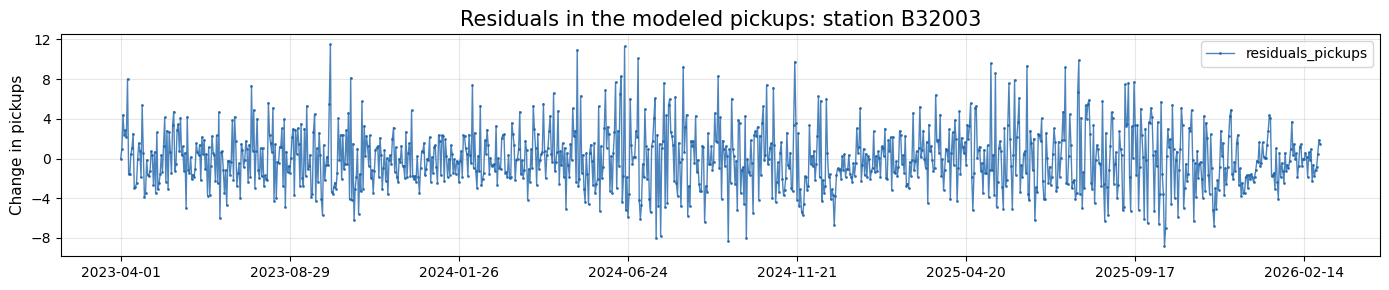

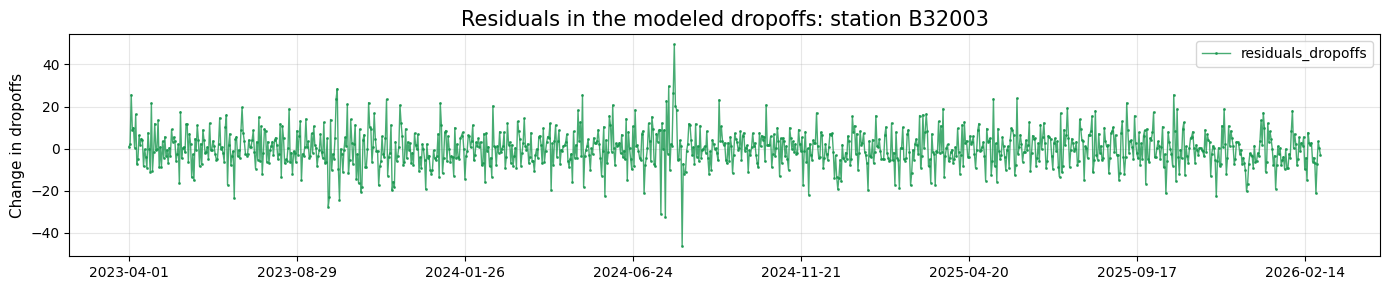

In [11]:
# Set index for plotting
df_daily_indexed = df_station.set_index('date')

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['residuals_pickups'],
    title=f'Residuals in the modeled pickups: station {station_name}',
    ylabel='Change in pickups',
    color_list=[COLORS[7]],
    figsize=(14, 3)
)

plot_daily_longterm(
    df_daily_indexed,
    columns_to_plot=['residuals_dropoffs'],
    title=f'Residuals in the modeled dropoffs: station {station_name}',
    ylabel='Change in dropoffs',
    color_list=[COLORS[5]],
    figsize=(14, 3)
)

### Cross-Correlation Analysis: Weather Effects

We now test whether weather variables explain variance in SARIMA residuals. Significant cross-correlations indicate weather effects independent of the temporal structure already captured by the model. For each weather variable, we examine correlations at multiple lags to identify both contemporaneous effects (lag 0) and lagged relationships (e.g., yesterday's temperature affecting today's demand). Variables showing significant correlations with residuals become candidates for inclusion as exogenous regressors in SARIMAX.

In [12]:
df_station = df_station.merge(df_weather, how="left", on="date")

In [13]:
set(df_weather.columns) - {"date"}

{'AWND', 'PRCP', 'SNOW', 'TMAX', 'TMIN'}

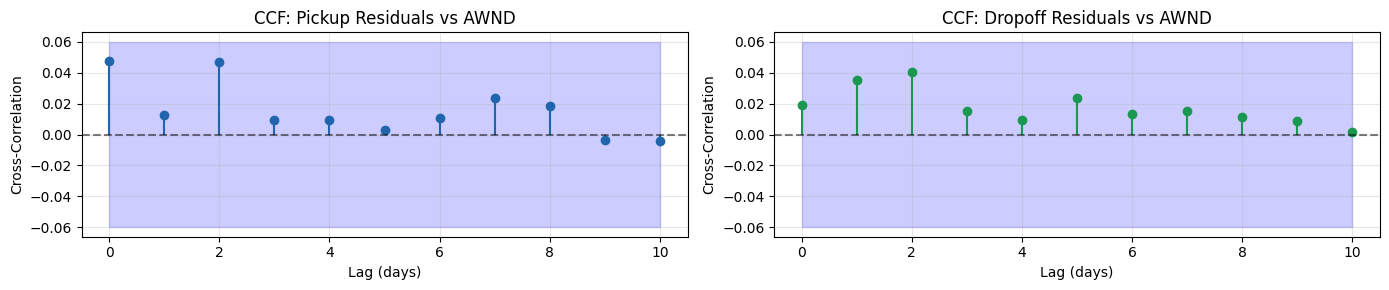

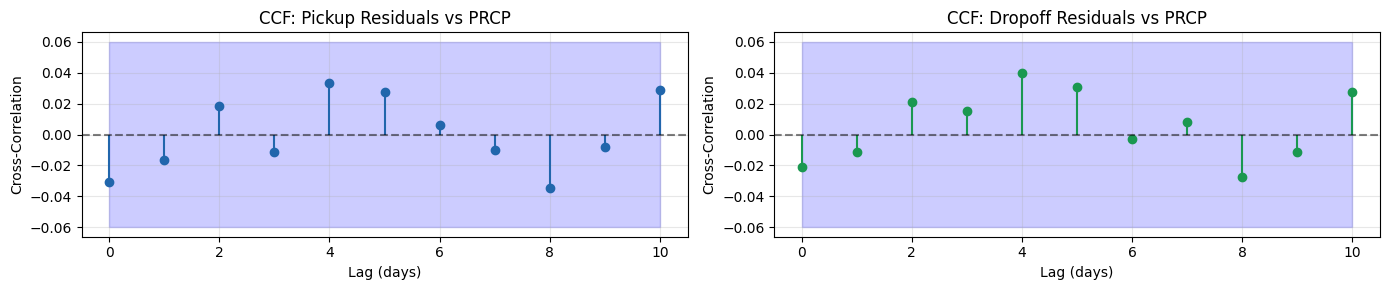

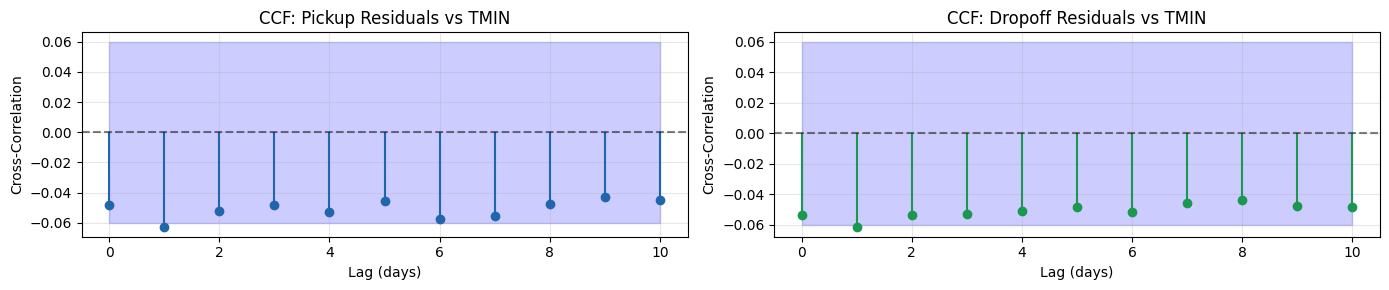

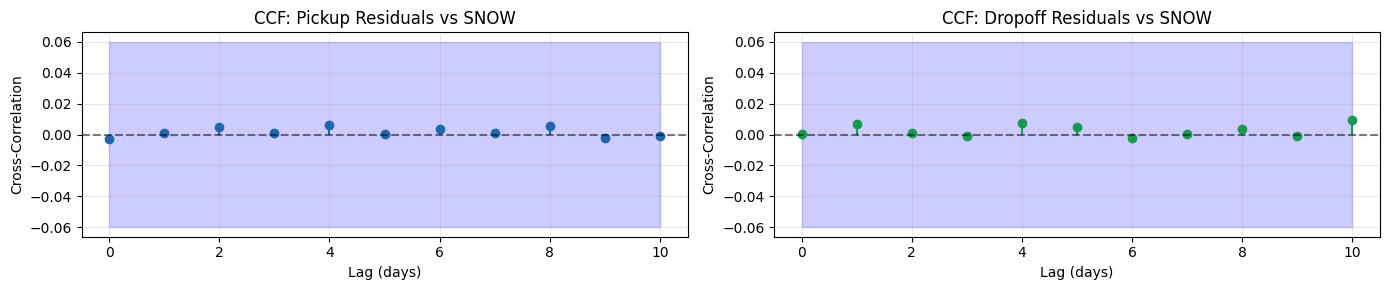

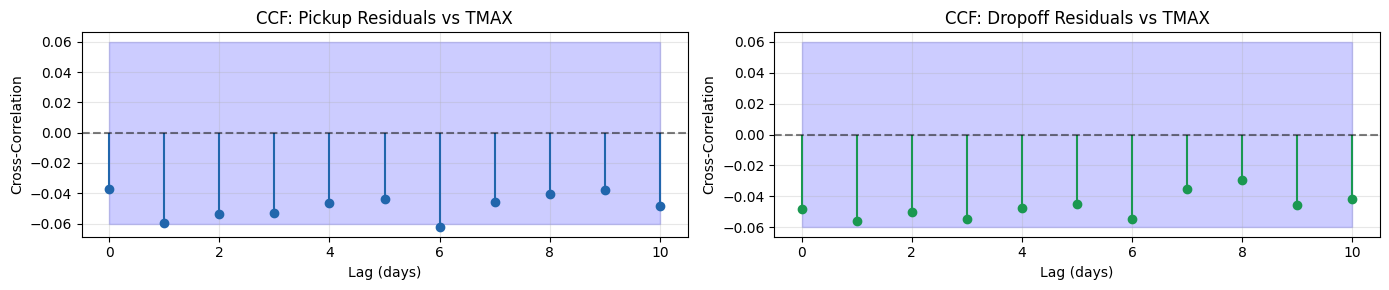

In [20]:
for col in set(df_weather.columns) - {"date"}:
    # Test TMAX against pickups and dropoffs residuals
    plot_crosscorrelation_comparison(
        df_station,
        columns_to_compare=["residuals_pickups", "residuals_dropoffs"],
        exog_column=col,
        titles=[f"CCF: Pickup Residuals vs {col}", f"CCF: Dropoff Residuals vs {col}"],
        color_list=[COLORS[7], COLORS[5]],
        lags=10,
        figsize=(14,3)
    )

Cross-correlation analysis between SARIMA residuals and weather variables reveals no significant correlations at tested lags, suggesting weather effects are already captured by the model structure. This likely occurs through two mechanisms: the MA(1) component absorbs day to day weather persistence (yesterday's weather-induced forecast error adjusts today's prediction for ongoing conditions), and first differencing removes annual weather cycles (winter cold, summer heat).

To confirm this interpretation, we examine cross-correlations between weather variables and the original demand series. If weather correlates with raw demand but not with residuals, this would verify that SARIMA's temporal structure implicitly accounts for weather influences, eliminating the need for explicit exogenous variables in SARIMAX.

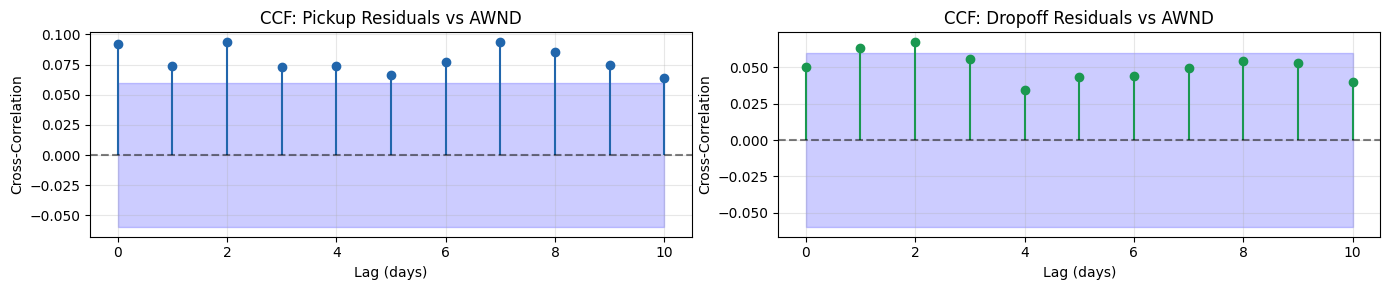

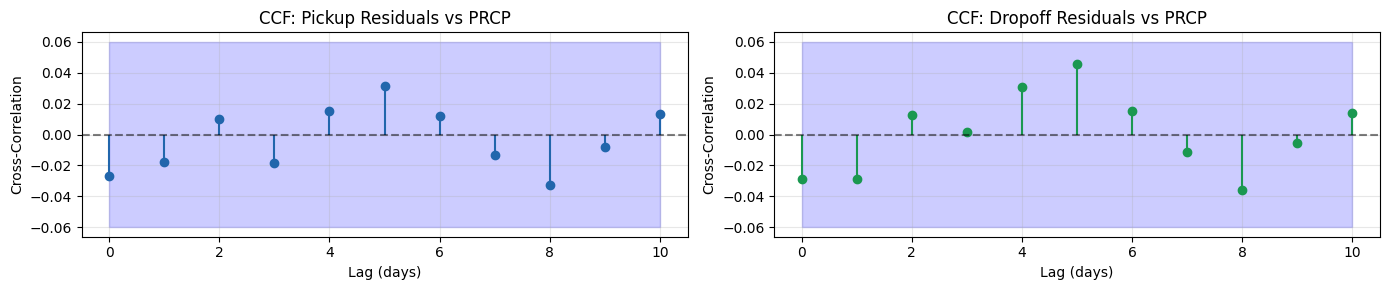

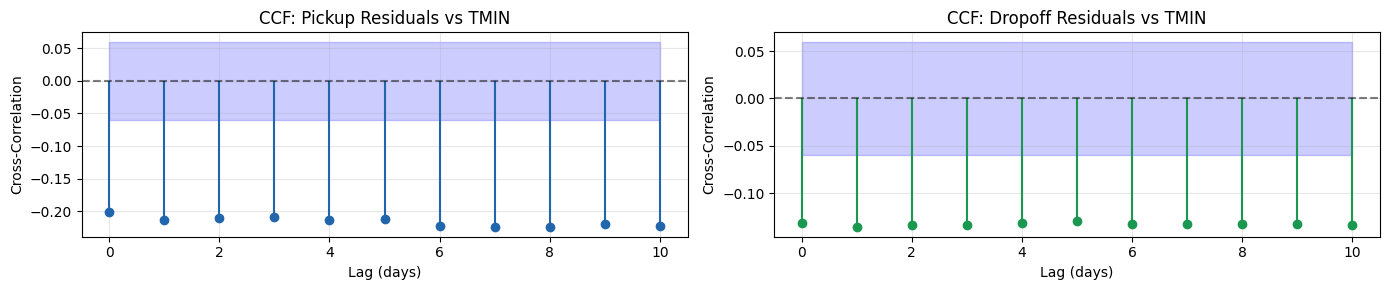

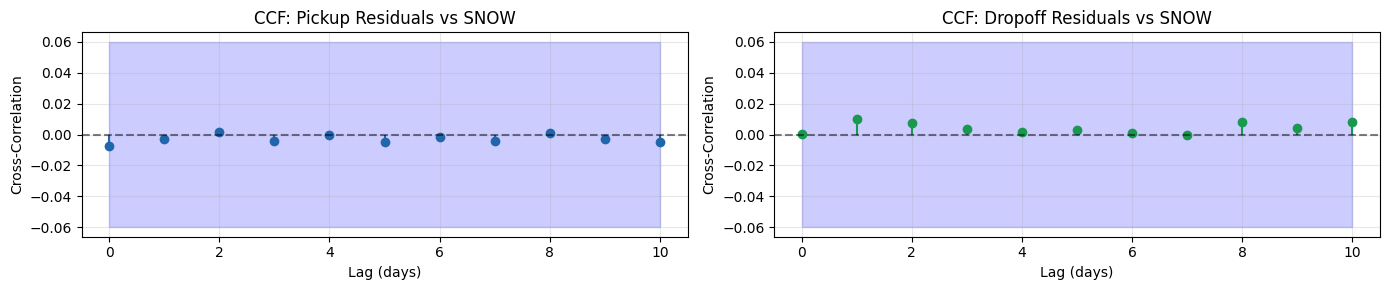

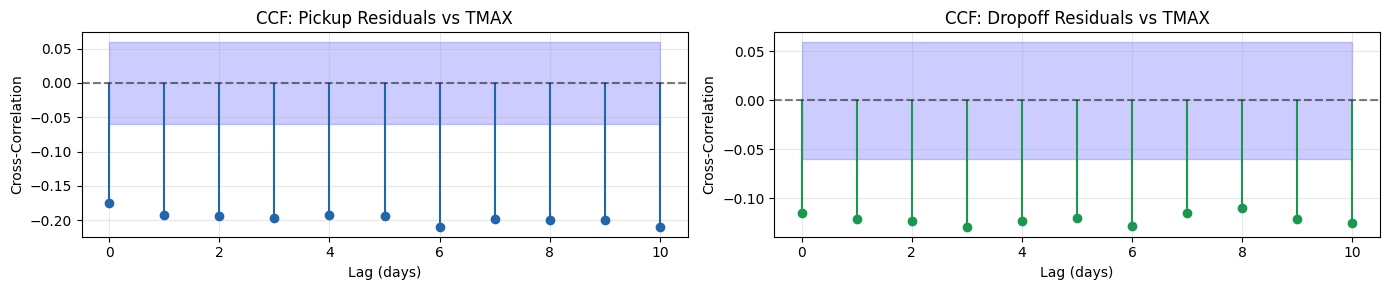

In [19]:
for col in set(df_weather.columns) - {"date"}:
    # Test TMAX against pickups and dropoffs residuals
    plot_crosscorrelation_comparison(
        df_station,
        columns_to_compare=["morning_pickups", "morning_dropoffs"],
        exog_column=col,
        titles=[f"CCF: Pickup Residuals vs {col}", f"CCF: Dropoff Residuals vs {col}"],
        color_list=[COLORS[7], COLORS[5]],
        lags=10,
        figsize=(14,3)
    )

Cross-correlation analysis confirms the hypothesis. Raw pickup demand shows significant negative correlation with temperature (ρ ≈ -0.15 to -0.20 with TMAX/TMIN) and weak positive correlation with wind speed (ρ ≈ 0.07 to 0.10), yet these correlations disappear when examining SARIMA residuals. This confirms weather effects are already captured by the model's temporal structure rather than representing independent predictive information.

The mechanisms are twofold: first differencing removes the annual temperature cycle (winter cold coinciding with seasonal demand suppression), and the MA(1) component absorbs day to day weather persistence (yesterday's weather induced forecast error adjusts today's prediction for ongoing conditions). The SARIMA(1,1,1)(1,0,0)₇ specification proves sufficient without explicit weather regressors, as temporal structure implicitly accounts for weather's influence on demand.

Note that weather variables may prove valuable in future machine learning approaches (gradient boosting, LSTM), which can capture nonlinear thresholds and interactions that linear SARIMAX cannot represent (e.g., demand drops sharply below 32°F, precipitation impact varies by temperature). For the current SARIMA framework, temporal structure alone provides adequate modeling.